In [1]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [3]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

VALID_EMOTIBIT_IDS = [
    "EmotiBit_1",
    "EmotiBit_2",
    "EmotiBit_3",
    "EmotiBit_4",
    "EmotiBit_6",
    "EmotiBit_7",
]

CANDIDATE_CLUSTER = ["EmotiBit_4", "EmotiBit_6", "EmotiBit_7"]

# Use winsorized HR for robustness
WINSOR_LOWER_Q = 0.05
WINSOR_UPPER_Q = 0.95

# Number of surrogates
N_SURROGATES = 2000

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [4]:
def load_group_hr(segment):
    path = PROCESSED_DIR / f"group_hr_{segment}_aligned_1s.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def winsorize_series(s, lower_q=0.05, upper_q=0.95):
    s = pd.Series(s).copy()
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)


def winsorize_df(df, columns, lower_q=0.05, upper_q=0.95):
    out = df.copy()
    for c in columns:
        out[c] = winsorize_series(out[c], lower_q=lower_q, upper_q=upper_q)
    return out


def pairwise_corr_long(df, subject_cols):
    rows = []
    for a, b in itertools.combinations(subject_cols, 2):
        x = df[a]
        y = df[b]
        valid = x.notna() & y.notna()
        n = int(valid.sum())

        if n < 3:
            r = np.nan
        else:
            r = x[valid].corr(y[valid])

        rows.append({
            "subject_a": a,
            "subject_b": b,
            "n_points": n,
            "corr": r,
        })
    return pd.DataFrame(rows)


def mean_pairwise_corr(corr_long_df):
    vals = corr_long_df["corr"].dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())


def cluster_pairwise_mean(corr_long_df, cluster_subjects):
    sub = corr_long_df[
        corr_long_df["subject_a"].isin(cluster_subjects) &
        corr_long_df["subject_b"].isin(cluster_subjects)
    ].copy()

    vals = sub["corr"].dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())


def circular_shift_array(x, shift):
    x = np.asarray(x)
    shift = int(shift) % len(x)
    if shift == 0:
        return x.copy()
    return np.roll(x, shift)


def circular_shift_df(df, subject_cols, rng):
    """
    Apply an independent random circular shift to each subject column.
    """
    out = df.copy()
    n = len(df)

    for c in subject_cols:
        shift = rng.integers(0, n)
        out[c] = circular_shift_array(out[c].values, shift)

    return out


def empirical_p_upper(observed, null_values):
    """
    One-sided p-value for observed being unusually large.
    """
    null_values = np.asarray(null_values, dtype=float)
    null_values = null_values[np.isfinite(null_values)]
    if len(null_values) == 0:
        return np.nan
    return float((np.sum(null_values >= observed) + 1) / (len(null_values) + 1))


def zscore_vs_null(observed, null_values):
    null_values = np.asarray(null_values, dtype=float)
    null_values = null_values[np.isfinite(null_values)]
    if len(null_values) < 2:
        return np.nan
    mu = np.mean(null_values)
    sd = np.std(null_values, ddof=1)
    if sd == 0 or np.isnan(sd):
        return np.nan
    return float((observed - mu) / sd)

In [5]:
observed_rows = []
segment_data = {}

for segment in SEGMENTS:
    df, path = load_group_hr(segment)
    if df is None:
        print("Missing:", path)
        continue

    subject_cols = [c for c in VALID_EMOTIBIT_IDS if c in df.columns]
    df_win = winsorize_df(df, subject_cols, WINSOR_LOWER_Q, WINSOR_UPPER_Q)

    corr_long = pairwise_corr_long(df_win, subject_cols)

    whole_mean = mean_pairwise_corr(corr_long)
    cluster_mean = cluster_pairwise_mean(corr_long, CANDIDATE_CLUSTER)

    observed_rows.append({
        "segment": segment,
        "n_timepoints": len(df_win),
        "observed_whole_group_mean_corr": whole_mean,
        "observed_cluster_467_mean_corr": cluster_mean,
    })

    segment_data[segment] = {
        "df_win": df_win,
        "subject_cols": subject_cols,
        "corr_long": corr_long,
    }

observed_df = pd.DataFrame(observed_rows)
display(observed_df)

,segment,n_timepoints,observed_whole_group_mean_corr,observed_cluster_467_mean_corr
0,pre_meditation,242,-0.001011,-0.025470
1,main_meditation,752,0.046693,0.212368
2,recovery,93,0.011486,-0.159539


In [6]:
surrogate_rows = []

for segment in SEGMENTS:
    if segment not in segment_data:
        continue

    df_win = segment_data[segment]["df_win"]
    subject_cols = segment_data[segment]["subject_cols"]

    for s in range(N_SURROGATES):
        df_surr = circular_shift_df(df_win, subject_cols, rng)
        corr_long_surr = pairwise_corr_long(df_surr, subject_cols)

        surrogate_rows.append({
            "segment": segment,
            "surrogate_id": s,
            "whole_group_mean_corr": mean_pairwise_corr(corr_long_surr),
            "cluster_467_mean_corr": cluster_pairwise_mean(corr_long_surr, CANDIDATE_CLUSTER),
        })

surrogate_df = pd.DataFrame(surrogate_rows)
display(surrogate_df.head())
print("Total surrogate rows:", len(surrogate_df))

,segment,surrogate_id,whole_group_mean_corr,cluster_467_mean_corr
0,pre_meditation,0,-0.037181,0.041444
1,pre_meditation,1,-0.057216,-0.085933
2,pre_meditation,2,0.016280,-0.015536
3,pre_meditation,3,0.011942,0.000654
4,pre_meditation,4,0.000215,0.000488


Total surrogate rows: 6000


In [7]:
out_path = TABLES_DIR / "group_synchrony_surrogate_distributions.csv"
surrogate_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_synchrony_surrogate_distributions.csv


In [8]:
test_rows = []

for _, obs in observed_df.iterrows():
    segment = obs["segment"]

    sub = surrogate_df[surrogate_df["segment"] == segment].copy()

    # Whole group
    obs_whole = obs["observed_whole_group_mean_corr"]
    null_whole = sub["whole_group_mean_corr"].values

    # Cluster
    obs_cluster = obs["observed_cluster_467_mean_corr"]
    null_cluster = sub["cluster_467_mean_corr"].values

    test_rows.append({
        "segment": segment,

        "observed_whole_group_mean_corr": obs_whole,
        "null_whole_mean": float(np.nanmean(null_whole)),
        "null_whole_std": float(np.nanstd(null_whole, ddof=1)),
        "whole_group_zscore": zscore_vs_null(obs_whole, null_whole),
        "whole_group_p_upper": empirical_p_upper(obs_whole, null_whole),

        "observed_cluster_467_mean_corr": obs_cluster,
        "null_cluster_mean": float(np.nanmean(null_cluster)),
        "null_cluster_std": float(np.nanstd(null_cluster, ddof=1)),
        "cluster_467_zscore": zscore_vs_null(obs_cluster, null_cluster),
        "cluster_467_p_upper": empirical_p_upper(obs_cluster, null_cluster),
    })

surrogate_test_summary = pd.DataFrame(test_rows)
display(surrogate_test_summary)

,segment,observed_whole_group_mean_corr,null_whole_mean,null_whole_std,whole_group_zscore,whole_group_p_upper,observed_cluster_467_mean_corr,null_cluster_mean,null_cluster_std,cluster_467_zscore,cluster_467_p_upper
0,pre_meditation,-0.001011,-0.000219,0.018365,-0.043102,0.500750,-0.025470,-0.001220,0.042961,-0.564465,0.709645
1,main_meditation,0.046693,-0.000312,0.016597,2.832057,0.007996,0.212368,-0.000092,0.060329,3.521653,0.001499
2,recovery,0.011486,0.000659,0.041952,0.258072,0.365317,-0.159539,0.001690,0.080286,-2.008171,0.978011


In [9]:
out_path = TABLES_DIR / "group_synchrony_surrogate_test_summary.csv"
surrogate_test_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_synchrony_surrogate_test_summary.csv


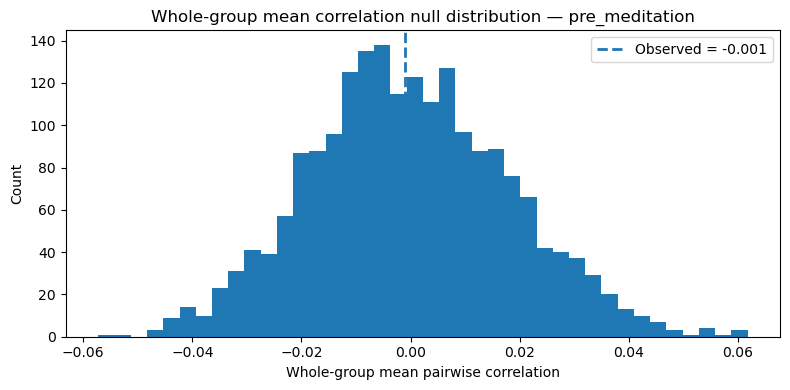

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_whole_group_pre_meditation.png


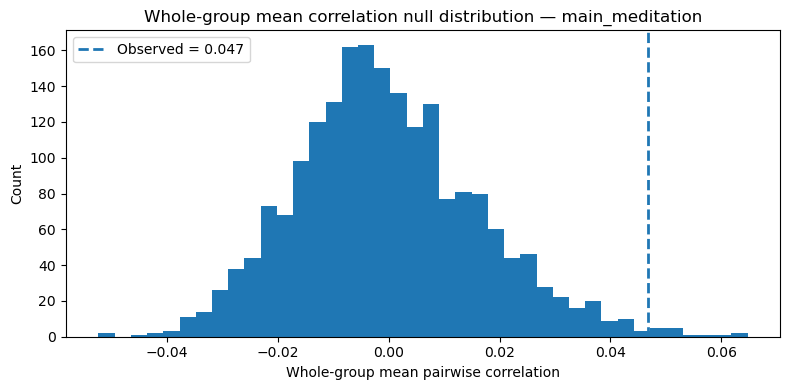

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_whole_group_main_meditation.png


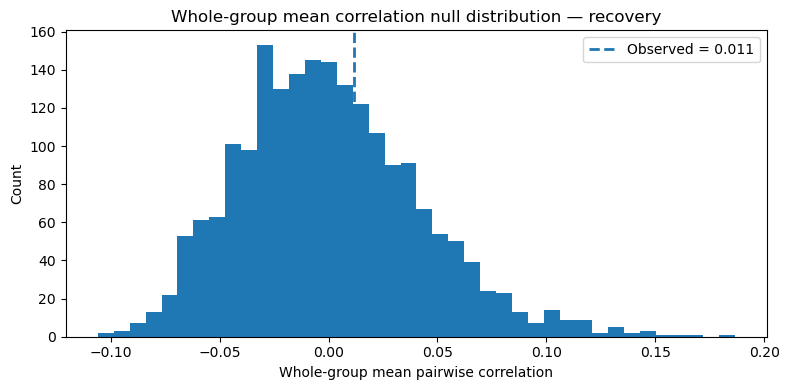

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_whole_group_recovery.png


In [10]:
for segment in SEGMENTS:
    sub = surrogate_df[surrogate_df["segment"] == segment].copy()
    if len(sub) == 0:
        continue

    obs = observed_df.loc[
        observed_df["segment"] == segment,
        "observed_whole_group_mean_corr"
    ].iloc[0]

    plt.figure(figsize=(8, 4))
    plt.hist(sub["whole_group_mean_corr"], bins=40)
    plt.axvline(obs, linestyle="--", linewidth=2, label=f"Observed = {obs:.3f}")
    plt.title(f"Whole-group mean correlation null distribution — {segment}")
    plt.xlabel("Whole-group mean pairwise correlation")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"null_whole_group_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

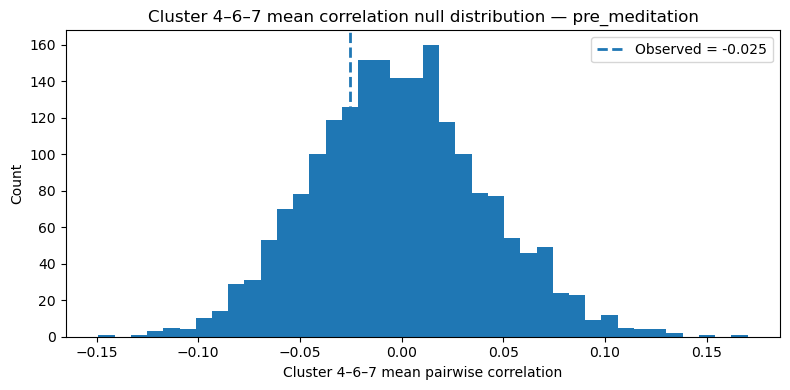

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_cluster_467_pre_meditation.png


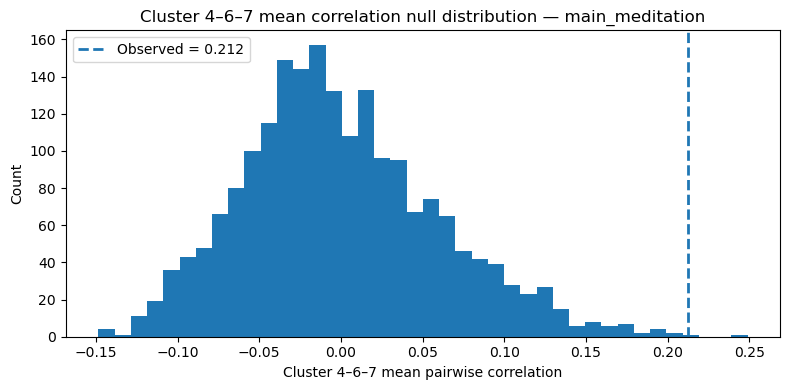

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_cluster_467_main_meditation.png


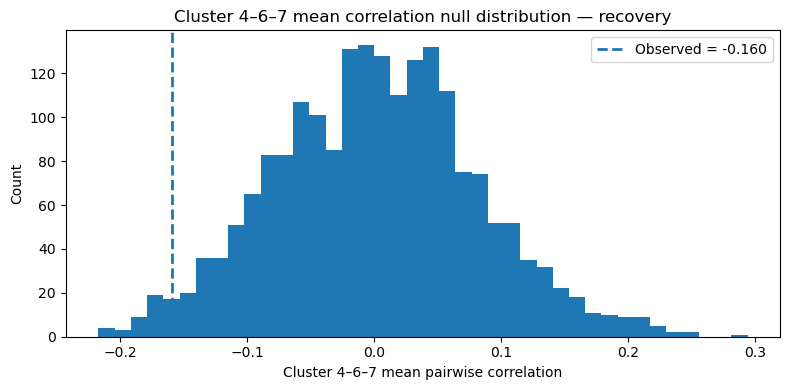

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_cluster_467_recovery.png


In [11]:
for segment in SEGMENTS:
    sub = surrogate_df[surrogate_df["segment"] == segment].copy()
    if len(sub) == 0:
        continue

    obs = observed_df.loc[
        observed_df["segment"] == segment,
        "observed_cluster_467_mean_corr"
    ].iloc[0]

    plt.figure(figsize=(8, 4))
    plt.hist(sub["cluster_467_mean_corr"], bins=40)
    plt.axvline(obs, linestyle="--", linewidth=2, label=f"Observed = {obs:.3f}")
    plt.title(f"Cluster 4–6–7 mean correlation null distribution — {segment}")
    plt.xlabel("Cluster 4–6–7 mean pairwise correlation")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"null_cluster_467_{segment}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [12]:
contrast_rows = []

metrics = [
    ("whole_group_mean_corr", "observed_whole_group_mean_corr"),
    ("cluster_467_mean_corr", "observed_cluster_467_mean_corr"),
]

for surrogate_metric, obs_metric in metrics:
    obs_main = observed_df.loc[observed_df["segment"] == "main_meditation", obs_metric].iloc[0]
    obs_pre = observed_df.loc[observed_df["segment"] == "pre_meditation", obs_metric].iloc[0]
    observed_diff = obs_main - obs_pre

    s_main = surrogate_df[surrogate_df["segment"] == "main_meditation"][surrogate_metric].values
    s_pre = surrogate_df[surrogate_df["segment"] == "pre_meditation"][surrogate_metric].values

    n = min(len(s_main), len(s_pre))
    null_diff = s_main[:n] - s_pre[:n]

    contrast_rows.append({
        "metric": surrogate_metric,
        "observed_main_minus_pre": observed_diff,
        "null_diff_mean": float(np.nanmean(null_diff)),
        "null_diff_std": float(np.nanstd(null_diff, ddof=1)),
        "zscore_main_minus_pre": zscore_vs_null(observed_diff, null_diff),
        "p_upper_main_greater_pre": empirical_p_upper(observed_diff, null_diff),
    })

contrast_df = pd.DataFrame(contrast_rows)
display(contrast_df)

,metric,observed_main_minus_pre,null_diff_mean,null_diff_std,zscore_main_minus_pre,p_upper_main_greater_pre
0,whole_group_mean_corr,0.047703,-0.000092,0.024853,1.923143,0.032984
1,cluster_467_mean_corr,0.237837,0.001128,0.075104,3.151773,0.001499


In [13]:
out_path = TABLES_DIR / "group_synchrony_main_vs_pre_contrast.csv"
contrast_df.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/group_synchrony_main_vs_pre_contrast.csv


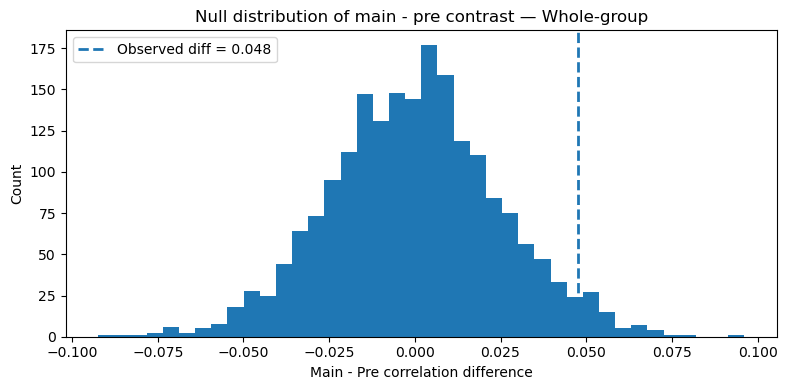

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_main_minus_pre_whole-group.png


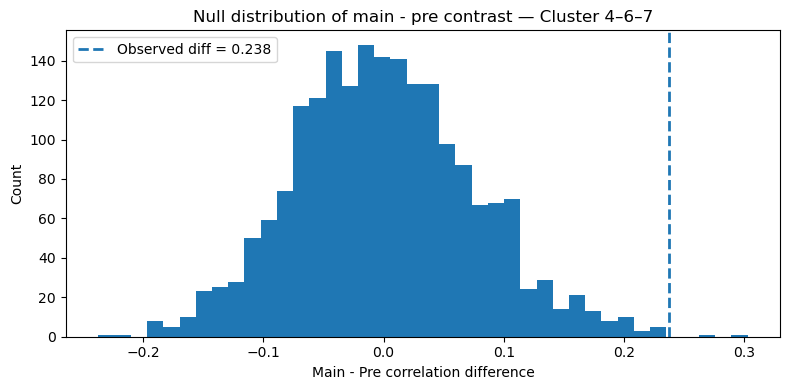

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/null_main_minus_pre_cluster_467.png


In [14]:
for surrogate_metric, obs_metric, label in [
    ("whole_group_mean_corr", "observed_whole_group_mean_corr", "Whole-group"),
    ("cluster_467_mean_corr", "observed_cluster_467_mean_corr", "Cluster 4–6–7"),
]:
    obs_main = observed_df.loc[observed_df["segment"] == "main_meditation", obs_metric].iloc[0]
    obs_pre = observed_df.loc[observed_df["segment"] == "pre_meditation", obs_metric].iloc[0]
    observed_diff = obs_main - obs_pre

    s_main = surrogate_df[surrogate_df["segment"] == "main_meditation"][surrogate_metric].values
    s_pre = surrogate_df[surrogate_df["segment"] == "pre_meditation"][surrogate_metric].values

    n = min(len(s_main), len(s_pre))
    null_diff = s_main[:n] - s_pre[:n]

    plt.figure(figsize=(8, 4))
    plt.hist(null_diff, bins=40)
    plt.axvline(observed_diff, linestyle="--", linewidth=2, label=f"Observed diff = {observed_diff:.3f}")
    plt.title(f"Null distribution of main - pre contrast — {label}")
    plt.xlabel("Main - Pre correlation difference")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"null_main_minus_pre_{label.replace('–','').replace(' ','_').lower()}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [15]:
final_summary = surrogate_test_summary.merge(
    contrast_df,
    how="cross"
)

print("Observed synchrony vs circular-shift nulls:")
display(surrogate_test_summary)

print("\nObserved main-minus-pre contrasts:")
display(contrast_df)

Observed synchrony vs circular-shift nulls:


,segment,observed_whole_group_mean_corr,null_whole_mean,null_whole_std,whole_group_zscore,whole_group_p_upper,observed_cluster_467_mean_corr,null_cluster_mean,null_cluster_std,cluster_467_zscore,cluster_467_p_upper
0,pre_meditation,-0.001011,-0.000219,0.018365,-0.043102,0.500750,-0.025470,-0.001220,0.042961,-0.564465,0.709645
1,main_meditation,0.046693,-0.000312,0.016597,2.832057,0.007996,0.212368,-0.000092,0.060329,3.521653,0.001499
2,recovery,0.011486,0.000659,0.041952,0.258072,0.365317,-0.159539,0.001690,0.080286,-2.008171,0.978011



Observed main-minus-pre contrasts:


,metric,observed_main_minus_pre,null_diff_mean,null_diff_std,zscore_main_minus_pre,p_upper_main_greater_pre
0,whole_group_mean_corr,0.047703,-0.000092,0.024853,1.923143,0.032984
1,cluster_467_mean_corr,0.237837,0.001128,0.075104,3.151773,0.001499


In [16]:
print("=== SURROGATE TESTING SUMMARY ===")
print("This notebook tested whether observed synchrony exceeds a circular-shift null.")
print("Key things to inspect:")
print("1. whole_group_p_upper")
print("2. cluster_467_p_upper")
print("3. p_upper_main_greater_pre for cluster_467_mean_corr")
print()
print("Interpretation:")
print("- low p for cluster 4-6-7 in main meditation supports a real subgroup synchrony effect")
print("- low p for main > pre supports meditation-specific synchrony increase")

=== SURROGATE TESTING SUMMARY ===
This notebook tested whether observed synchrony exceeds a circular-shift null.
Key things to inspect:
1. whole_group_p_upper
2. cluster_467_p_upper
3. p_upper_main_greater_pre for cluster_467_mean_corr

Interpretation:
- low p for cluster 4-6-7 in main meditation supports a real subgroup synchrony effect
- low p for main > pre supports meditation-specific synchrony increase
